<a href="https://colab.research.google.com/github/leolabs-id/datascience-learning-homework/blob/main/customer_segmentation_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
customer_info = pd.read_csv('segmentation_data.csv')
customer_info

,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,100000001,0,0,67,2,124670,1,2
1,100000002,1,1,22,1,150773,1,2
2,100000003,0,0,49,1,89210,0,0
3,100000004,0,0,45,1,171565,1,1
4,100000005,0,0,53,1,149031,1,1
...,...,...,...,...,...,...,...,...
1995,100001996,1,0,47,1,123525,0,0
1996,100001997,1,1,27,1,117744,1,0
1997,100001998,0,0,31,0,86400,0,0
1998,100001999,1,1,24,1,97968,0,0


In [3]:
customer_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   ID               2000 non-null   int64
 1   Sex              2000 non-null   int64
 2   Marital status   2000 non-null   int64
 3   Age              2000 non-null   int64
 4   Education        2000 non-null   int64
 5   Income           2000 non-null   int64
 6   Occupation       2000 non-null   int64
 7   Settlement size  2000 non-null   int64
dtypes: int64(8)
memory usage: 125.1 KB


In [4]:
customer_info.describe()

,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
count,2.000000e+03,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1.000010e+08,0.457000,0.496500,35.909000,1.03800,120954.419000,0.810500,0.739000
std,5.774946e+02,0.498272,0.500113,11.719402,0.59978,38108.824679,0.638587,0.812533
min,1.000000e+08,0.000000,0.000000,18.000000,0.00000,35832.000000,0.000000,0.000000
25%,1.000005e+08,0.000000,0.000000,27.000000,1.00000,97663.250000,0.000000,0.000000
50%,1.000010e+08,0.000000,0.000000,33.000000,1.00000,115548.500000,1.000000,1.000000
75%,1.000015e+08,1.000000,1.000000,42.000000,1.00000,138072.250000,1.000000,1.000000
max,1.000020e+08,1.000000,1.000000,76.000000,3.00000,309364.000000,2.000000,2.000000


In [5]:
num_col = ['Age','Income']
cat_col = ['Sex', 'Marital status', 'Education', 'Occupation', 'Settlement size']

In [6]:
df = customer_info.copy()

In [7]:
df[cat_col] = df[cat_col].astype('str')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   ID               2000 non-null   int64 
 1   Sex              2000 non-null   object
 2   Marital status   2000 non-null   object
 3   Age              2000 non-null   int64 
 4   Education        2000 non-null   object
 5   Income           2000 non-null   int64 
 6   Occupation       2000 non-null   object
 7   Settlement size  2000 non-null   object
dtypes: int64(3), object(5)
memory usage: 125.1+ KB


#Distribusi Variabel Numerik

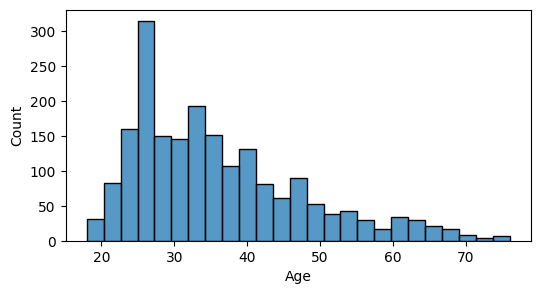

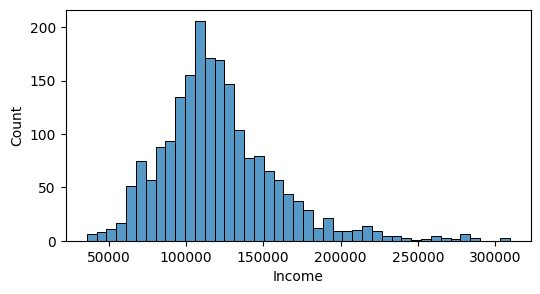

In [9]:
for num in num_col:
    plt.figure(figsize=(6,3))
    sns.histplot(data = customer_info, x = num)

#Distribusi variabel kategorikal

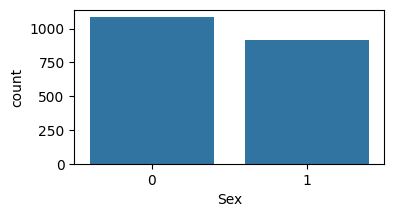

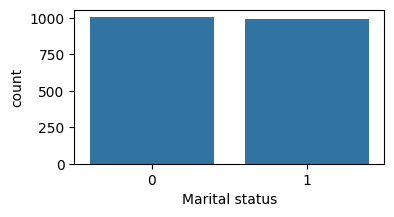

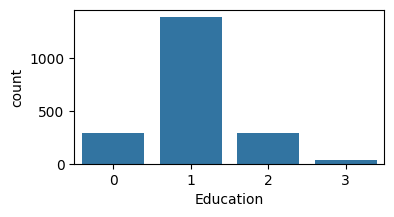

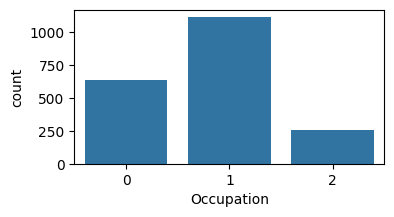

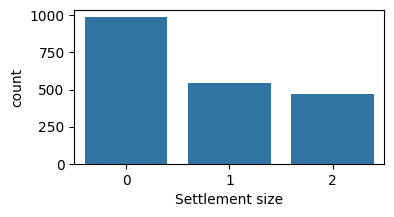

In [10]:
for cat in cat_col:
    plt.figure(figsize = (4, 2))
    sns.countplot(data = customer_info, x = cat)

# Analisis bivariat antara variabel numerik

<Axes: xlabel='Age', ylabel='Income'>

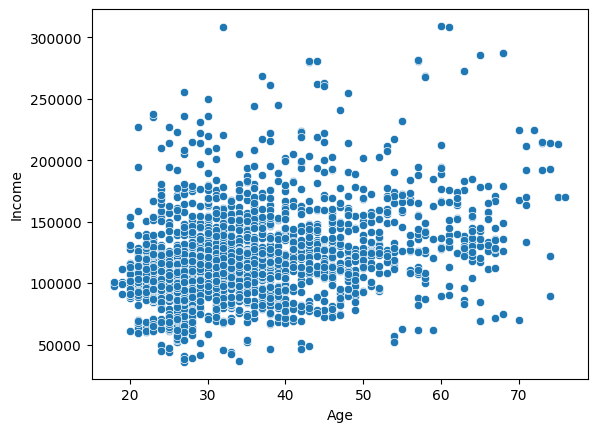

In [11]:
sns.scatterplot(x = 'Age', y = 'Income', data = customer_info)

In [12]:
import scipy.stats as stats

stats.pearsonr(customer_info['Age'], customer_info['Income']) # menghitung korelasi antar dau variabel numerik

PearsonRResult(statistic=np.float64(0.3406101637317351), pvalue=np.float64(1.6443825442386297e-55))

#Analisis bivariat antar kolom kategorikal dengan numerikal

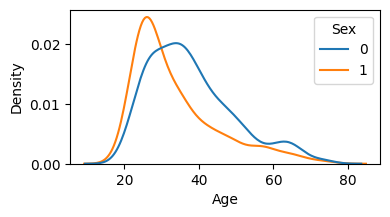

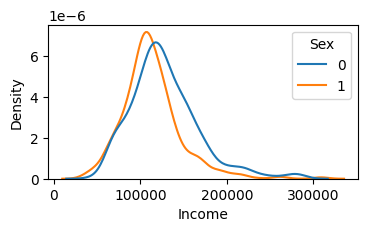

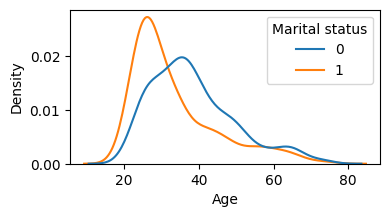

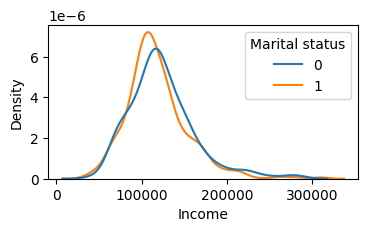

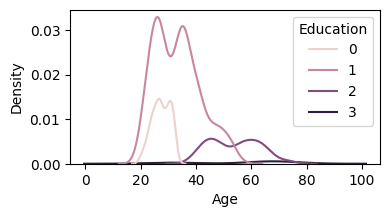

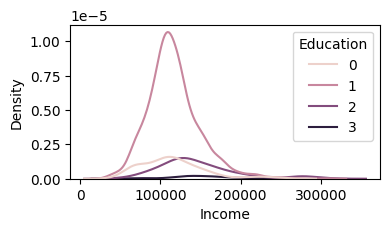

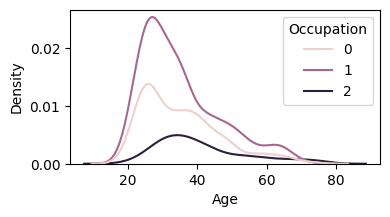

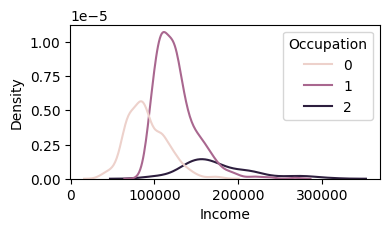

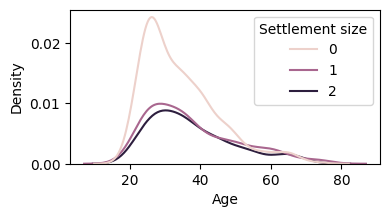

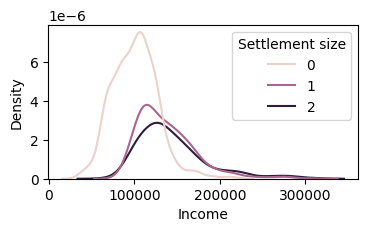

In [13]:
for cat in cat_col:
    for num in num_col:
      plt.figure(figsize = (4, 2))
      sns.kdeplot(data = customer_info, x = num, hue = cat)

#Analisis bivariat antar kolom kategorikal

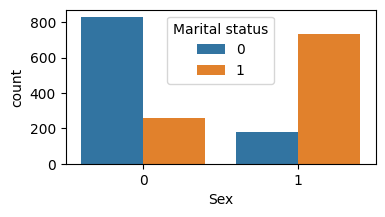

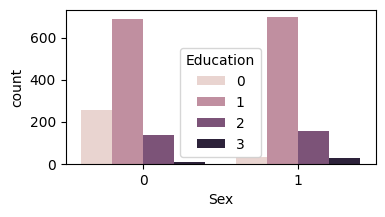

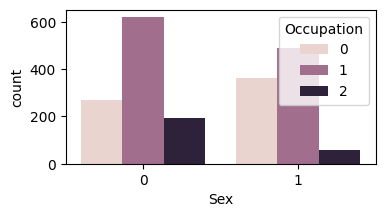

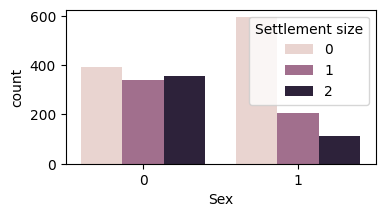

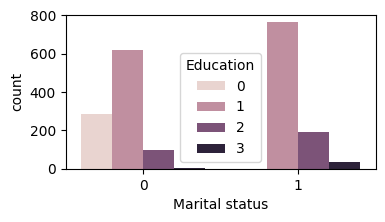

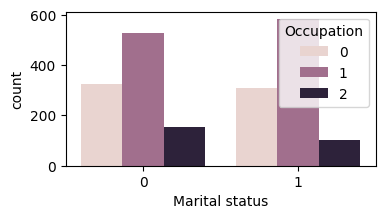

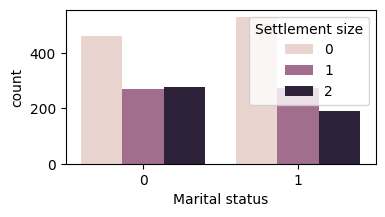

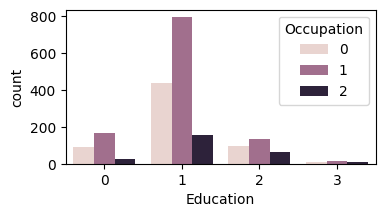

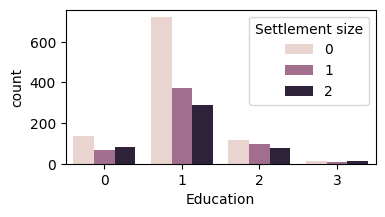

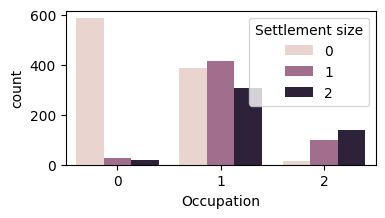

In [14]:
cat_aux = cat_col.copy()
for category1 in cat_col:
    cat_aux.pop(0);
    for category2 in cat_aux:
        if category1 != category2:
            plt.figure(figsize=(4,2))
            sns.countplot(data=customer_info, x=category1, hue=category2)

# Analisis Multivariat

In [15]:
def bivariate_scatter(x, y, hue, df):
    plt.figure(figsize=(6,6))
    sns.scatterplot(x=x, y=y, data=df, hue=hue, alpha=0.85)

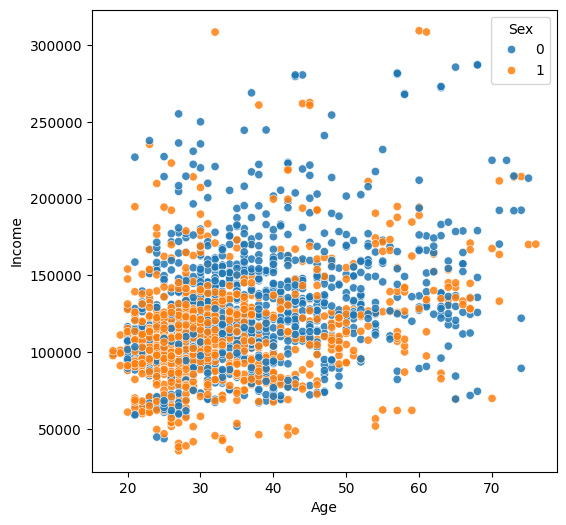

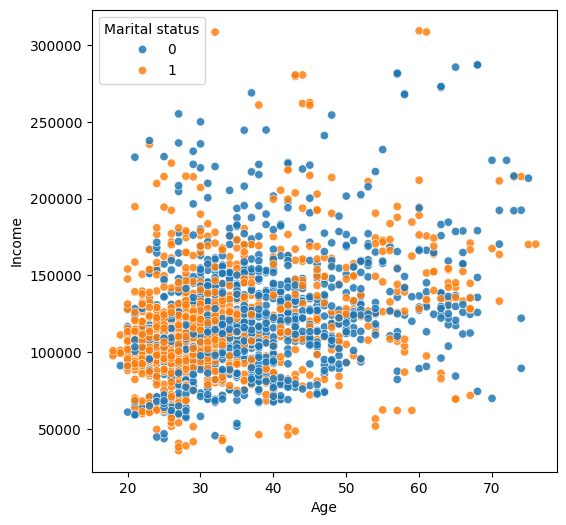

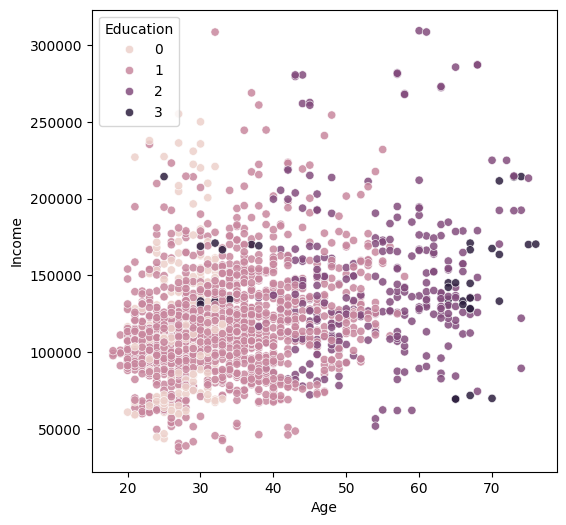

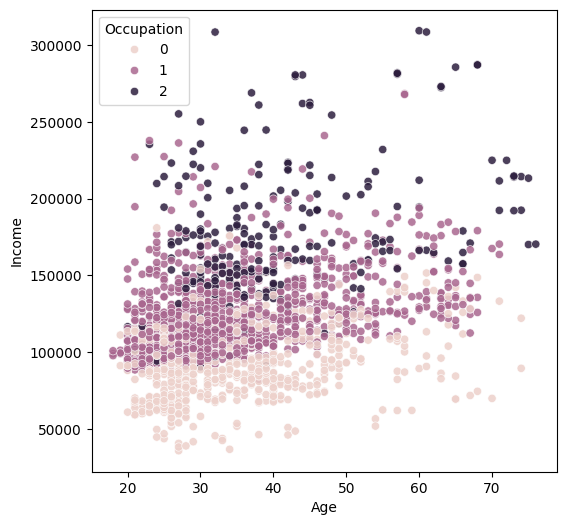

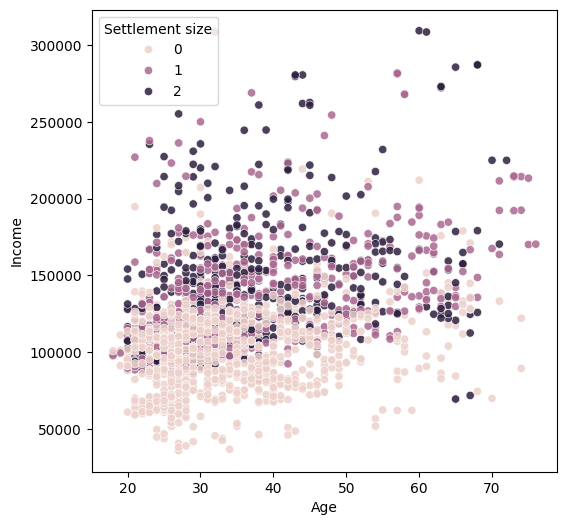

In [16]:
for cat in cat_col:
    bivariate_scatter('Age', 'Income', cat, customer_info)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   ID               2000 non-null   int64 
 1   Sex              2000 non-null   object
 2   Marital status   2000 non-null   object
 3   Age              2000 non-null   int64 
 4   Education        2000 non-null   object
 5   Income           2000 non-null   int64 
 6   Occupation       2000 non-null   object
 7   Settlement size  2000 non-null   object
dtypes: int64(3), object(5)
memory usage: 125.1+ KB


# Pre-Processing

In [18]:
df = customer_info.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   ID               2000 non-null   int64
 1   Sex              2000 non-null   int64
 2   Marital status   2000 non-null   int64
 3   Age              2000 non-null   int64
 4   Education        2000 non-null   int64
 5   Income           2000 non-null   int64
 6   Occupation       2000 non-null   int64
 7   Settlement size  2000 non-null   int64
dtypes: int64(8)
memory usage: 125.1 KB


In [19]:
df

,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,100000001,0,0,67,2,124670,1,2
1,100000002,1,1,22,1,150773,1,2
2,100000003,0,0,49,1,89210,0,0
3,100000004,0,0,45,1,171565,1,1
4,100000005,0,0,53,1,149031,1,1
...,...,...,...,...,...,...,...,...
1995,100001996,1,0,47,1,123525,0,0
1996,100001997,1,1,27,1,117744,1,0
1997,100001998,0,0,31,0,86400,0,0
1998,100001999,1,1,24,1,97968,0,0


In [20]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X = scaler.fit_transform(df)

In [21]:
pd.DataFrame(X, columns = df.columns).describe()

,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.500000,0.457000,0.496500,0.308776,0.346000,0.311197,0.405250,0.369500
std,0.288892,0.498272,0.500113,0.202059,0.199927,0.139321,0.319294,0.406266
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.250000,0.000000,0.000000,0.155172,0.333333,0.226048,0.000000,0.000000
50%,0.500000,0.000000,0.000000,0.258621,0.333333,0.291434,0.500000,0.500000
75%,0.750000,1.000000,1.000000,0.413793,0.333333,0.373778,0.500000,0.500000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# Buat Model Clustering

In [22]:
## hapus kolom id
X = X[:, 1:]

In [23]:
pd.DataFrame(X)

,0,1,2,3,4,5,6
0,0.0,0.0,0.844828,0.666667,0.324781,0.5,1.0
1,1.0,1.0,0.068966,0.333333,0.420210,0.5,1.0
2,0.0,0.0,0.534483,0.333333,0.195144,0.0,0.0
3,0.0,0.0,0.465517,0.333333,0.496223,0.5,0.5
4,0.0,0.0,0.603448,0.333333,0.413842,0.5,0.5
...,...,...,...,...,...,...,...
1995,1.0,0.0,0.500000,0.333333,0.320595,0.0,0.0
1996,1.0,1.0,0.155172,0.333333,0.299460,0.5,0.0
1997,0.0,0.0,0.224138,0.000000,0.184871,0.0,0.0
1998,1.0,1.0,0.103448,0.333333,0.227162,0.0,0.0


# Metode Elbow untuk menentukan banyaknya cluster yang nanti akan di-generate oleh model ML clustering

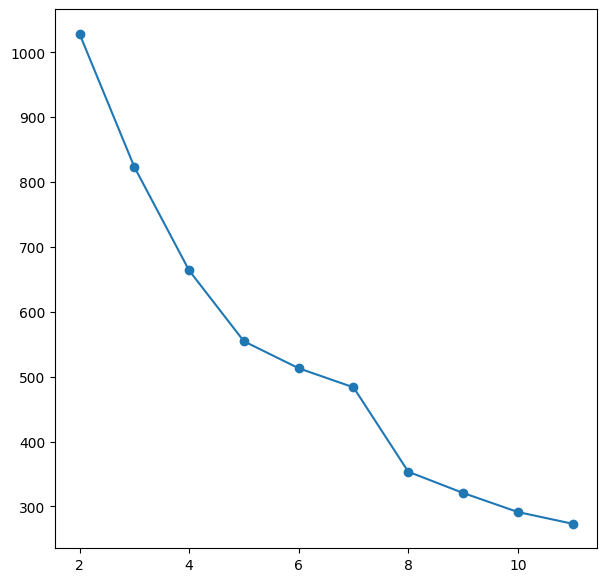

In [24]:
from sklearn.cluster import KMeans

# pilihan jml cluster
clusters_range = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
inertia = []

for c in clusters_range:
    kmeans = KMeans(n_clusters = c, random_state = 42).fit(X) # training clustering ke dalam c cluster dg Kmeans
    inertia.append(kmeans.inertia_)

plt.figure(figsize = (7, 7))
plt.plot(clusters_range, inertia, marker = 'o')

# Menentukan berapa jumlah cluster yg akan digenerate dengan Sillhouette Score

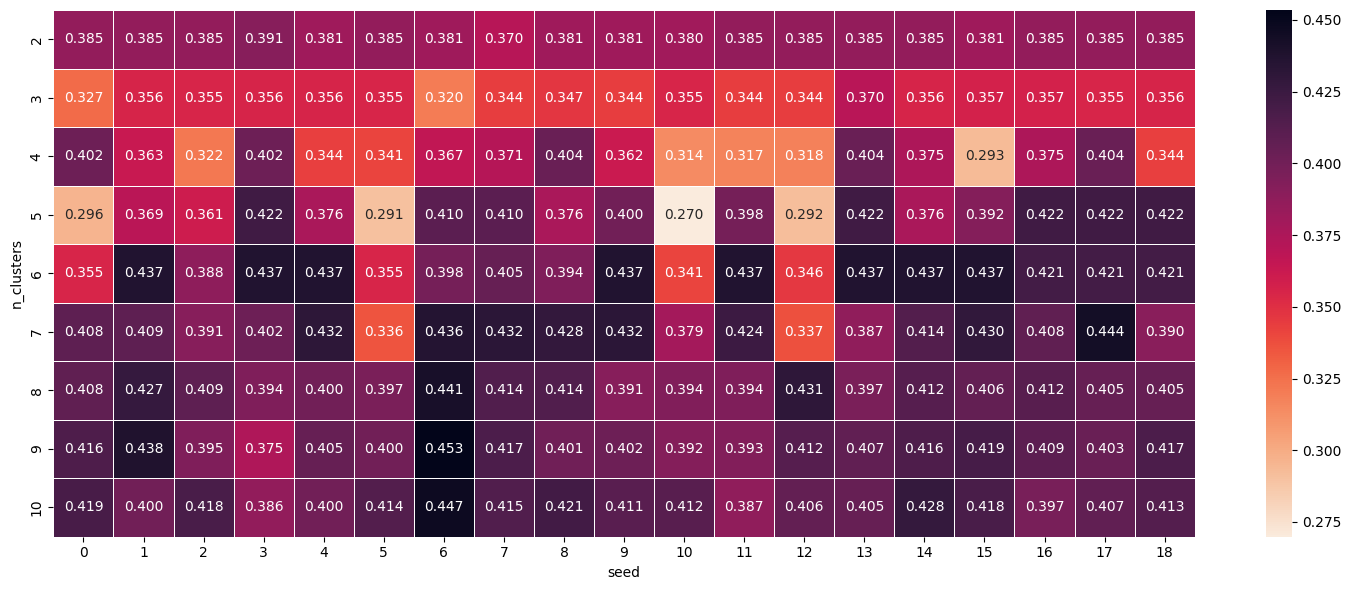

In [25]:
from sklearn.metrics import silhouette_samples, silhouette_score

clusters_range=range(2, 11)
random_range  =range(0, 19)
results=[]

for c in clusters_range:
    for r in random_range:
        clusterer = KMeans(n_clusters = c, random_state = r)
        cluster_labels = clusterer.fit_predict(X)
        sillhouette_avg = silhouette_score(X, cluster_labels)
        results.append([c, r, sillhouette_avg])

result = pd.DataFrame(results, columns=["n_clusters","seed","silhouette_score"])
pivot_km = pd.pivot_table(result, index="n_clusters", columns="seed",values="silhouette_score")

plt.figure(figsize=(15, 6))
sns.heatmap(pivot_km, annot=True, linewidths=.5, fmt='.3f', cmap=sns.cm.rocket_r)
plt.tight_layout()

dari hasil elbow method dan sillhouette score, kita akan bagi customer ke dalam 6 kelompok

# Jalankan algoritma KMeans untuk membagi customer ke dalam 6 kelompok



In [26]:
kmeans = KMeans(n_clusters=6, random_state=0).fit(X) # proses training algoritma KMeans untuk membagi dataset ke dalam 6 kelompok
labels = kmeans.labels_

In [27]:
results_df = customer_info.copy()
results_df['Labels'] = kmeans.labels_
results_df

,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size,Labels
0,100000001,0,0,67,2,124670,1,2,2
1,100000002,1,1,22,1,150773,1,2,4
2,100000003,0,0,49,1,89210,0,0,3
3,100000004,0,0,45,1,171565,1,1,0
4,100000005,0,0,53,1,149031,1,1,0
...,...,...,...,...,...,...,...,...,...
1995,100001996,1,0,47,1,123525,0,0,3
1996,100001997,1,1,27,1,117744,1,0,1
1997,100001998,0,0,31,0,86400,0,0,3
1998,100001999,1,1,24,1,97968,0,0,1


In [28]:
results_df['Labels'].value_counts()

,count
Labels,
1,430
0,371
3,358
4,308
2,276
5,257


In [29]:
summary = {}

for index in range(6):
   # describe method provides general statistics about the data
   summary[index] = results_df[results_df['Labels'] == index].describe().T

In [30]:
summary[0]

,count,mean,std,min,25%,50%,75%,max
ID,371.0,1.000008e+08,505.819135,100000004.0,100000351.5,100000707.0,100001138.5,100001995.0
Sex,371.0,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,0.0
Marital status,371.0,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,0.0
Age,371.0,3.956873e+01,11.470408,20.0,31.0,37.0,47.0,75.0
Education,371.0,8.221024e-01,0.597876,0.0,0.0,1.0,1.0,2.0
Income,371.0,1.363733e+05,34209.316029,82398.0,114452.0,126906.0,150123.5,281923.0
Occupation,371.0,1.102426e+00,0.441459,0.0,1.0,1.0,1.0,2.0
Settlement size,371.0,6.954178e-01,0.460852,0.0,0.0,1.0,1.0,1.0
Labels,371.0,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,0.0


In [31]:
summary[1]

,count,mean,std,min,25%,50%,75%,max
ID,430.0,1.000013e+08,562.136063,100000011.0,1.000008e+08,100001478.0,1.000017e+08,100001999.0
Sex,430.0,1.000000e+00,0.000000,1.0,1.000000e+00,1.0,1.000000e+00,1.0
Marital status,430.0,1.000000e+00,0.000000,1.0,1.000000e+00,1.0,1.000000e+00,1.0
Age,430.0,3.241628e+01,10.911221,18.0,2.500000e+01,28.5,3.600000e+01,71.0
Education,430.0,1.211628e+00,0.467453,1.0,1.000000e+00,1.0,1.000000e+00,3.0
Income,430.0,1.021423e+05,25801.373992,35832.0,8.628125e+04,102323.5,1.204592e+05,207262.0
Occupation,430.0,4.279070e-01,0.495352,0.0,0.000000e+00,0.0,1.000000e+00,1.0
Settlement size,430.0,1.162791e-02,0.107329,0.0,0.000000e+00,0.0,0.000000e+00,1.0
Labels,430.0,1.000000e+00,0.000000,1.0,1.000000e+00,1.0,1.000000e+00,1.0


# Visualisasi hasil clustering

In [32]:
pd.DataFrame(X)

,0,1,2,3,4,5,6
0,0.0,0.0,0.844828,0.666667,0.324781,0.5,1.0
1,1.0,1.0,0.068966,0.333333,0.420210,0.5,1.0
2,0.0,0.0,0.534483,0.333333,0.195144,0.0,0.0
3,0.0,0.0,0.465517,0.333333,0.496223,0.5,0.5
4,0.0,0.0,0.603448,0.333333,0.413842,0.5,0.5
...,...,...,...,...,...,...,...
1995,1.0,0.0,0.500000,0.333333,0.320595,0.0,0.0
1996,1.0,1.0,0.155172,0.333333,0.299460,0.5,0.0
1997,0.0,0.0,0.224138,0.000000,0.184871,0.0,0.0
1998,1.0,1.0,0.103448,0.333333,0.227162,0.0,0.0


In [33]:
# pengurangan dimensi dataset training kita, dari 7 dimensi ke dalam 3 dimensi menggunakan algoritma PCA (Principal Component Analysis)

from sklearn.decomposition import PCA

pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X) # fit-> mempelajari data X, tranform -> mengubah X yg tadinya 7 dimensi menjadi 3 dimensi saja
X_pca_df = pd.DataFrame(data=X_pca, columns=['X1', 'X2', 'X3'])
X_pca_df

,X1,X2,X3
0,-0.826086,0.354652,0.158422
1,0.524891,0.716293,0.240947
2,-0.486009,-0.690668,-0.181594
3,-0.707351,-0.028668,0.044773
4,-0.712574,-0.037939,0.046813
...,...,...,...
1995,0.195388,-0.680837,0.550240
1996,0.793264,-0.016224,0.007582
1997,-0.494899,-0.746080,-0.189808
1998,0.875828,-0.285273,-0.094256


In [34]:
X_pca_df['Labels'] = labels
X_pca_df['Labels'] = X_pca_df['Labels'].astype(str)

X_pca_df

,X1,X2,X3,Labels
0,-0.826086,0.354652,0.158422,2
1,0.524891,0.716293,0.240947,4
2,-0.486009,-0.690668,-0.181594,3
3,-0.707351,-0.028668,0.044773,0
4,-0.712574,-0.037939,0.046813,0
...,...,...,...,...
1995,0.195388,-0.680837,0.550240,3
1996,0.793264,-0.016224,0.007582,1
1997,-0.494899,-0.746080,-0.189808,3
1998,0.875828,-0.285273,-0.094256,1


In [35]:
import plotly.express as px

fig = px.scatter_3d(X_pca_df, x='X1', y='X2', z='X3',
              color=X_pca_df['Labels'])
fig.show()

In [36]:
summary[5]

,count,mean,std,min,25%,50%,75%,max
ID,257.0,1.000009e+08,506.080683,100000009.0,100000434.0,100000914.0,100001192.0,100001971.0
Sex,257.0,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,0.0
Marital status,257.0,1.000000e+00,0.000000,1.0,1.0,1.0,1.0,1.0
Age,257.0,3.396887e+01,10.759035,18.0,26.0,31.0,40.0,67.0
Education,257.0,1.268482e+00,0.501851,1.0,1.0,1.0,1.0,3.0
Income,257.0,1.229767e+05,38529.241076,62263.0,96769.0,115369.0,146519.0,280570.0
Occupation,257.0,9.338521e-01,0.630834,0.0,1.0,1.0,1.0,2.0
Settlement size,257.0,9.182879e-01,0.827468,0.0,0.0,1.0,2.0,2.0
Labels,257.0,5.000000e+00,0.000000,5.0,5.0,5.0,5.0,5.0
